# Train Politeness Model bằng XLM-R

Notebook train model đánh giá **sự lịch sự và tôn trọng** trong hội thoại CSKH.

Dữ liệu:
```text
data/raw/auxiliary_pretrain_baseline/03_politeness_respect/
data/processed/politeness/
data/raw/custom_labeled/politeness/
```

Nhãn:
```text
0 = impolite
1 = neutral
2 = polite
```

**Complete Pipeline version:** đã bổ sung Initial EDA, Final Preprocessing, Post-preprocessing Summary, Model Selection Comparison và Macro-F1 metrics.

In [1]:
!pip install pandas scikit-learn  transformers datasets accelerate tqdm -q

In [3]:
import re
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

POLITENESS_DATA_DIR = Path("data/raw/auxiliary_pretrain_baseline/03_politeness_respect")
LABELED_DATA_DIRS = [Path("data/processed/politeness"), Path("data/raw/custom_labeled/politeness")]
OUTPUT_DIR = Path("models/politeness_xlm_roberta")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 256
TEST_SIZE = 0.15
VALID_SIZE = 0.15
RANDOM_SEED = 42
NUM_EPOCHS = 5
BATCH_SIZE = 8
LEARNING_RATE = 5e-5

id2label = {0: "impolite", 1: "neutral", 2: "polite"}
label2id = {"impolite": 0, "neutral": 1, "polite": 2}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("POLITENESS_DATA_DIR:", POLITENESS_DATA_DIR)

Torch: 2.12.1+cpu
CUDA available: False
POLITENESS_DATA_DIR: data\raw\auxiliary_pretrain_baseline\03_politeness_respect


## Initial EDA and Final Preprocessing Utilities

Các hàm dưới đây dùng chung cho notebook:

1. **Initial EDA**: kiểm tra dữ liệu trước khi bước clean/final preprocessing cuối cùng.
2. **Final preprocessing**: loại missing text/label, bỏ text quá ngắn, bỏ duplicate.
3. **Post-preprocessing summary**: kiểm tra lại dữ liệu sạch trước khi chia train/validation/test.


### Vì sao một số cell không hiện output?

Các cell chứa `def ...` chỉ **định nghĩa hàm** nên bình thường không tạo bảng/biểu đồ. Output EDA sẽ xuất hiện ở các cell gọi hàm như `run_initial_eda(...)` và `run_post_preprocessing_summary(...)`. Notebook bản này đã thêm `print(...)` ở cuối các cell tiện ích để bạn biết cell đã chạy thành công.

In [4]:
# ============================================================
# Initial EDA and Final Preprocessing Utilities
# ============================================================

import matplotlib.pyplot as plt


def _label_series_to_name(series, label_map=None):
    """Chuyển đổi ID nhãn sang tên nhãn để hiển thị biểu đồ trực quan hơn."""
    if label_map is None:
        return series.astype(str)
    return series.map(label_map).fillna(series.astype(str))


def run_initial_eda(data, text_col="text", label_col="label", label_map=None, title="INITIAL EDA ON DATA BEFORE FINAL PREPROCESSING"):
    """
    Phân tích dữ liệu thô. 
    CẢI TIẾN: Thêm kiểm tra sự mâu thuẫn nhãn (cùng 1 câu nhưng khác nhãn).
    """
    print(f"{'='*30} {title} {'='*30}")

    # Kiểm tra sự mâu thuẫn (cùng text nhưng khác label)
    conflicts = data.groupby(text_col)[label_col].nunique()
    conflict_count = (conflicts > 1).sum()
    if conflict_count > 0:
        print(f"CẢNH BÁO: Có {conflict_count} câu bị gán nhiều nhãn khác nhau. Điều này gây nhiễu cho model!")

    print("Shape:", data.shape)
    print("\nColumns:")
    print(list(data.columns))

    print("\nData types:")
    display(data.dtypes)

    print("\nFirst 10 rows:")
    display(data.head(10))

    print("\nMissing values:")
    display(data.isna().sum().sort_values(ascending=False))

    print("\nDuplicated full rows:", data.duplicated().sum())

    if text_col in data.columns:
        tmp = data.copy()
        tmp["word_count"] = tmp[text_col].astype(str).apply(lambda x: len(x.split()))

        # In ra phân vị 95% để biết nên đặt MAX_LENGTH là bao nhiêu
        print("\nPhân vị 95% độ dài câu (Nên đặt MAX_LENGTH gần con số này):")
        print(tmp["word_count"].quantile(0.95))
        
        print(f"Duplicated `{text_col}` values:", data[text_col].duplicated().sum())
        tmp = data.copy()
        tmp["text_length_char"] = tmp[text_col].astype(str).apply(len)
        tmp["text_length_word"] = tmp[text_col].astype(str).apply(lambda x: len(x.split()))

        print("\nText length by characters:")
        display(tmp["text_length_char"].describe())
        print("\nText length by words:")
        display(tmp["text_length_word"].describe())

        plt.figure(figsize=(8, 5))
        tmp["text_length_word"].plot(kind="hist", bins=50)
        plt.title("Initial EDA - Text Length Distribution by Words")
        plt.xlabel("Number of words")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

    if label_col in data.columns:
        label_names = _label_series_to_name(data[label_col], label_map)
        print("\nLabel distribution:")
        display(label_names.value_counts(dropna=False))

        plt.figure(figsize=(8, 5))
        label_names.value_counts(dropna=False).plot(kind="bar")
        plt.title("Initial EDA - Label Distribution")
        plt.xlabel("Label")
        plt.ylabel("Number of samples")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

        if text_col in data.columns:
            tmp = data.copy()
            tmp["label_name"] = label_names
            tmp["text_length_word"] = tmp[text_col].astype(str).apply(lambda x: len(x.split()))
            print("\nText length by label:")
            display(tmp.groupby("label_name")["text_length_word"].agg(["count", "mean", "median", "min", "max"]))

    for col in ["source_file", "source_type", "label_type", "pseudo_label"]:
        if col in data.columns:
            print(f"\nDistribution of `{col}`:")
            display(data[col].value_counts(dropna=False).head(20))


def preprocess_final_dataframe(data, text_col="text", label_col="label", min_text_length=2):
    """Final preprocessing before split/train."""
    cleaned = data.copy()

    if text_col not in cleaned.columns:
        raise ValueError(f"Missing text column: {text_col}")
    if label_col not in cleaned.columns:
        raise ValueError(f"Missing label column: {label_col}")

    before = len(cleaned)
    cleaned[text_col] = cleaned[text_col].fillna("").astype(str).str.strip()
    cleaned = cleaned[cleaned[text_col].str.len() >= min_text_length]
    cleaned = cleaned[cleaned[label_col].notna()]
    cleaned[label_col] = cleaned[label_col].astype(int)
    cleaned = cleaned.drop_duplicates(subset=[text_col, label_col]).reset_index(drop=True)

    print("=" * 90)
    print("FINAL PREPROCESSING SUMMARY")
    print("=" * 90)
    print("Rows before final preprocessing:", before)
    print("Rows after final preprocessing :", len(cleaned))
    print("Rows removed                  :", before - len(cleaned))

    return cleaned


def run_post_preprocessing_summary(data, text_col="text", label_col="label", label_map=None):
    print("=" * 90)
    print("POST-PREPROCESSING DATA SUMMARY")
    print("=" * 90)
    print("Shape:", data.shape)
    print("Missing values:")
    display(data.isna().sum())
    print(f"Duplicated `{text_col}` + `{label_col}` pairs:", data.duplicated(subset=[text_col, label_col]).sum())

    label_names = _label_series_to_name(data[label_col], label_map) if label_col in data.columns else None
    if label_names is not None:
        print("\nLabel distribution after preprocessing:")
        display(label_names.value_counts())

        plt.figure(figsize=(8, 5))
        label_names.value_counts().plot(kind="bar")
        plt.title("Post-preprocessing Label Distribution")
        plt.xlabel("Label")
        plt.ylabel("Number of samples")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    if text_col in data.columns:
        tmp = data.copy()
        tmp["text_length_word"] = tmp[text_col].astype(str).apply(lambda x: len(x.split()))
        print("\nText length after preprocessing:")
        display(tmp["text_length_word"].describe())

        if label_names is not None:
            tmp["label_name"] = label_names
            print("\nText length after preprocessing by label:")
            display(tmp.groupby("label_name")["text_length_word"].agg(["count", "mean", "median", "min", "max"]))


print("EDA and preprocessing utility functions loaded successfully. Continue running the next data-loading cells.")

EDA and preprocessing utility functions loaded successfully. Continue running the next data-loading cells.


In [5]:
def normalize_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    # Loại bỏ emoji hoặc ký tự đặc biệt không cần thiết (tùy chọn)
    text = re.sub(r"[^\w\s.,!?<>]", "", text) 
    text = re.sub(r"http\S+|www\S+", " <url> ", text)
    text = re.sub(r"\S+@\S+", " <email> ", text)
    # Cải tiến: xử lý số điện thoại đa dạng hơn
    text = re.sub(r"0\d{9,10}", " <phone> ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def read_csv_robust(csv_path):
    try:
        return pd.read_csv(csv_path)
    except Exception:
        return pd.read_csv(csv_path, engine="python", on_bad_lines="skip", encoding="utf-8")

def map_politeness_label(value):
    if pd.isna(value):
        return None
    raw = str(value).strip().lower()
    impolite = ["impolite","rude","toxic","offensive","not_polite","unpolite","negative","bất lịch sự","bat lich su","thiếu lịch sự","thieu lich su","0"]
    neutral = ["neutral","normal","somewhat polite","somewhat_polite","mixed","trung lập","trung lap","1"]
    polite = ["polite","very polite","very_polite","respectful","positive","lịch sự","lich su","rất lịch sự","rat lich su","2"]
    if raw in impolite:
        return 0
    if raw in neutral:
        return 1
    if raw in polite:
        return 2
    try:
        score = float(raw)
        if -1 <= score <= 1:
            if score < -0.2:
                return 0
            if score <= 0.2:
                return 1
            return 2
        if score <= 2:
            return 0
        if score == 3:
            return 1
        if score >= 4:
            return 2
    except Exception:
        print(f"Warning: Unknown label found: {value}")
        return None
    return None

TEXT_COL_CANDIDATES = ["text","prompt","completion","sentence","utterance","request","response","content","comment","input","output"]
LABEL_COL_CANDIDATES = ["label","label_cat","label_noisy","label_cat_noisy","politeness","politeness_label","politeness_score","score","rating","class","target"]

def find_column(columns, candidates):
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

def build_politeness_input(row):
    customer_cols = ["customer_text","user_text","client_text","khach_hang","customer"]
    agent_cols = ["agent_text","staff_text","employee_text","assistant_text","bot_text","nhan_vien","response","completion"]
    customer_parts, agent_parts = [], []
    for col in customer_cols:
        if col in row and pd.notna(row[col]) and str(row[col]).strip():
            customer_parts.append(str(row[col]))
    for col in agent_cols:
        if col in row and pd.notna(row[col]) and str(row[col]).strip():
            agent_parts.append(str(row[col]))
    if customer_parts or agent_parts:
        text = ""
        if customer_parts:
            text += "Khách hàng: " + " ".join(customer_parts) + " "
        if agent_parts:
            text += "Nhân viên: " + " ".join(agent_parts)
        return text.strip()
    if "prompt" in row and "completion" in row:
        prompt = str(row["prompt"]) if pd.notna(row["prompt"]) else ""
        completion = str(row["completion"]) if pd.notna(row["completion"]) else ""
        if prompt.strip() or completion.strip():
            return f"{prompt} {completion}".strip()
    for col in TEXT_COL_CANDIDATES:
        if col in row and pd.notna(row[col]) and str(row[col]).strip():
            return str(row[col])
    return ""

print("Text normalization / loading helper functions loaded successfully.")

Text normalization / loading helper functions loaded successfully.


In [ ]:
def create_politeness_annotation_template():
    out_dir = Path("data/processed/politeness")
    out_dir.mkdir(parents=True, exist_ok=True)
    template_path = out_dir / "politeness_annotation_template.csv"
    if not template_path.exists():
        cols = ["conversation_id","conversation_text","customer_text","agent_text","politeness_label","politeness_score","annotator","notes"]
        pd.DataFrame(columns=cols).to_csv(template_path, index=False, encoding="utf-8-sig")
    guide = """# Hướng dẫn gán nhãn Politeness

## Quy tắc gán nhãn:
- **impolite (0)**: Thô lỗ, dùng từ ngữ xúc phạm, thái độ bề trên, từ chối không lý do.
  *Ví dụ: "Làm gì có chuyện đó vớ vẩn"*
- **neutral (1)**: Chỉ đưa thông tin thuần túy, không có từ ngữ biểu cảm, mang tính robot.
  *Ví dụ: "Sản phẩm của bạn đã được gửi."*
- **polite (2)**: Dùng kính ngữ, xin lỗi, cảm ơn, giải thích tận tình.
  *Ví dụ: "Vâng, rất xin lỗi anh về sự cố này, để em kiểm tra ngay giúp anh."*

## Lưu ý:
- Nếu là câu chat ngắn ngủi "Ok", "Vâng" -> Hãy đánh vào nhãn neutral.
"""
    guide_path = out_dir / "POLITENESS_LABELING_GUIDE.md"
    guide_path.write_text(guide, encoding="utf-8")
    print("Template:", template_path)
    print("Guide:", guide_path)

create_politeness_annotation_template()

Template: data\processed\politeness\politeness_annotation_template.csv
Guide: data\processed\politeness\POLITENESS_LABELING_GUIDE.md


In [6]:
def load_human_labeled_politeness_data(search_dirs):
    rows = []
    for data_dir in search_dirs:
        if not data_dir.exists():
            continue
        for csv_path in data_dir.rglob("*.csv"):
            if any(x in csv_path.name.lower() for x in ["prediction","summary","dataset_info"]):
                continue
            try:
                df = read_csv_robust(csv_path)
            except Exception as e:
                print(f"Không đọc được: {csv_path} | lỗi: {e}")
                continue
            label_col = find_column(df.columns, LABEL_COL_CANDIDATES)
            if label_col is None:
                continue
            used = 0
            for _, row in df.iterrows():
                text = build_politeness_input(row)
                label = map_politeness_label(row[label_col])
                if label is None:
                    continue
                text = normalize_text(text)
                if len(text) < 3:
                    continue
                rows.append({"text": text, "label": label, "source_file": str(csv_path), "source_type": "human_labeled"})
                used += 1
            if used:
                print(f"Đã load {used} dòng có nhãn thật từ: {csv_path}")
    data = pd.DataFrame(rows)
    if not data.empty:
        data = data.drop_duplicates(subset=["text","label"]).reset_index(drop=True)
    return data

def load_public_politeness_data(data_dir):
    rows = []
    if not data_dir.exists():
        print("Không tìm thấy folder:", data_dir)
        return pd.DataFrame(rows)
    csv_files = list(data_dir.rglob("*.csv"))
    print(f"Tìm thấy {len(csv_files)} file CSV trong {data_dir}")
    for csv_path in csv_files:
        if any(x in csv_path.name.lower() for x in ["prediction","summary","dataset_info"]):
            continue
        try:
            df = read_csv_robust(csv_path)
        except Exception as e:
            print(f"Không đọc được: {csv_path} | lỗi: {e}")
            continue
        text_col = find_column(df.columns, TEXT_COL_CANDIDATES)
        label_col = find_column(df.columns, LABEL_COL_CANDIDATES)
        has_prompt_completion = "prompt" in df.columns and "completion" in df.columns
        if text_col is None and not has_prompt_completion:
            print(f"Bỏ qua vì không có cột text phù hợp: {csv_path}")
            print("Columns:", list(df.columns))
            continue
        if label_col is None:
            print(f"Bỏ qua vì không có cột label phù hợp: {csv_path}")
            print("Columns:", list(df.columns))
            continue
        used = 0
        print("\nĐang xử lý:", csv_path)
        print("Text column :", text_col)
        print("Label column:", label_col)
        print("Rows:", len(df))
        for _, row in df.iterrows():
            text = build_politeness_input(row)
            label = map_politeness_label(row[label_col])
            if label is None:
                continue
            text = normalize_text(text)
            if len(text) < 3:
                continue
            rows.append({"text": text, "label": label, "source_file": str(csv_path), "source_type": "public_politeness"})
            used += 1
        print(f"Đã load {used} dòng từ file này.")
    data = pd.DataFrame(rows)
    if not data.empty:
        data = data.drop_duplicates(subset=["text","label"]).reset_index(drop=True)
    return data

def build_synthetic_vietnamese_politeness_data():
    samples = [
        ("Khách hàng: Tôi muốn đổi sản phẩm vì bị lỗi. Nhân viên: Không đổi được, bạn tự kiểm tra lại đi.", 0),
        ("Khách hàng: Tôi chờ đơn hàng lâu quá rồi. Nhân viên: Chờ đi, bên tôi chưa xử lý.", 0),
        ("Khách hàng: Tôi bị trừ tiền nhưng chưa có đơn. Nhân viên: Tôi không biết, bạn hỏi ngân hàng đi.", 0),
        ("Khách hàng: Sản phẩm giao sai màu. Nhân viên: Sai thì gửi lại, nói nhiều làm gì.", 0),
        ("Khách hàng: Tôi cần hỗ trợ bảo hành. Nhân viên: Không đọc chính sách à?", 0),
        ("Khách hàng: Tôi muốn kiểm tra đơn hàng. Nhân viên: Bạn gửi mã đơn hàng.", 1),
        ("Khách hàng: Tôi muốn đổi địa chỉ giao hàng. Nhân viên: Gửi thông tin địa chỉ mới.", 1),
        ("Khách hàng: Tôi cần hỏi về chính sách đổi trả. Nhân viên: Bạn xem trong phần chính sách đổi trả.", 1),
        ("Khách hàng: Đơn hàng của tôi đang ở đâu? Nhân viên: Mã đơn hàng là gì?", 1),
        ("Khách hàng: Tôi muốn hủy đơn. Nhân viên: Cung cấp mã đơn hàng để kiểm tra.", 1),
        ("Khách hàng: Tôi muốn kiểm tra đơn hàng. Nhân viên: Dạ anh/chị cho em xin mã đơn hàng để em hỗ trợ kiểm tra ngay ạ.", 2),
        ("Khách hàng: Tôi muốn đổi địa chỉ giao hàng. Nhân viên: Dạ anh/chị vui lòng gửi em địa chỉ mới, em sẽ kiểm tra xem đơn còn hỗ trợ đổi được không ạ.", 2),
        ("Khách hàng: Tôi cần hỏi về chính sách đổi trả. Nhân viên: Dạ em xin phép gửi anh/chị thông tin chính sách đổi trả và sẽ hỗ trợ mình nếu cần thêm thông tin ạ.", 2),
        ("Khách hàng: Đơn hàng của tôi đang ở đâu? Nhân viên: Dạ anh/chị cho em xin mã đơn hàng, em sẽ kiểm tra tình trạng vận chuyển giúp mình ngay ạ.", 2),
        ("Khách hàng: Tôi muốn hủy đơn. Nhân viên: Dạ anh/chị cho em xin mã đơn hàng để em kiểm tra trạng thái và hỗ trợ hủy đơn nếu còn kịp ạ.", 2),
    ]
    return pd.DataFrame([{"text": normalize_text(t), "label": y, "source_file": "synthetic_vietnamese_cskh", "source_type": "synthetic_vietnamese_cskh"} for t, y in samples])

In [7]:
df_human = load_human_labeled_politeness_data(LABELED_DATA_DIRS)
df_public = load_public_politeness_data(POLITENESS_DATA_DIR)
df_synthetic = build_synthetic_vietnamese_politeness_data()

print("\nDữ liệu human-labeled:", len(df_human))
print("Dữ liệu public politeness:", len(df_public))
print("Dữ liệu synthetic tiếng Việt:", len(df_synthetic))

df_list = []
if not df_human.empty:
    df_list.append(df_human)
if not df_public.empty:
    df_list.append(df_public)
if not df_synthetic.empty:
    df_list.append(df_synthetic)
if not df_list:
    raise ValueError("Không tìm thấy dữ liệu politeness để train.")

df = pd.concat(df_list, ignore_index=True)
df = df.drop_duplicates(subset=["text","label"]).reset_index(drop=True)

print("\nTổng số dòng dùng train:", len(df))
print("\nPhân bố nhãn:")
print(df["label"].map(id2label).value_counts())
print("\nPhân bố source_type:")
print(df["source_type"].value_counts())
display(df.head(10))

Tìm thấy 7 file CSV trong data\raw\auxiliary_pretrain_baseline\03_politeness_respect

Đang xử lý: data\raw\auxiliary_pretrain_baseline\03_politeness_respect\politeness_corpus_frfede\train.csv
Text column : text
Label column: label
Rows: 16428
Đã load 16428 dòng từ file này.

Đang xử lý: data\raw\auxiliary_pretrain_baseline\03_politeness_respect\polite_guard\test.csv
Text column : text
Label column: label
Rows: 10200
Đã load 10200 dòng từ file này.

Đang xử lý: data\raw\auxiliary_pretrain_baseline\03_politeness_respect\polite_guard\train.csv
Text column : text
Label column: label
Rows: 80000
Đã load 80000 dòng từ file này.

Đang xử lý: data\raw\auxiliary_pretrain_baseline\03_politeness_respect\polite_guard\validation.csv
Text column : text
Label column: label
Rows: 10000
Đã load 10000 dòng từ file này.
Bỏ qua vì không có cột label phù hợp: data\raw\auxiliary_pretrain_baseline\03_politeness_respect\stanford_politeness\fine-tuning_train.csv
Columns: ['prompt', 'completion']
Bỏ qua vì khôn

,text,label,source_file,source_type
0,"is it an ordered list? ie, will the cells appe...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
1,"in the bike lane, obviously. what're they gonn...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
2,what version of bash are you using? is it 4.x ...,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
3,there are many factors that influence the layo...,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
4,i'm afraid i don't know what you mean arcayne....,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
5,well? what do you think?,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
6,"""i + have"" = proper agreement; ""she + is"" = ag...",1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
7,what if you attach the mdf file to sql server ...,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
8,and wasting our time as well. i can only repea...,0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
9,"i'm happy to help! after all, what's the point...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness


## Initial Exploratory Data Analysis Before Final Preprocessing

EDA được thực hiện trước bước clean/final preprocessing cuối cùng để kiểm tra kích thước dữ liệu, missing values, duplicates, phân bố nhãn, độ dài văn bản và nguồn dữ liệu. Dựa trên kết quả này, notebook mới thực hiện bước preprocessing cuối cùng trước khi chia train/validation/test.


INITIAL EDA BEFORE FINAL PREPROCESSING
Shape: (111214, 4)

Columns:
['text', 'label', 'source_file', 'source_type']

Data types:


text           object
label           int64
source_file    object
source_type    object
dtype: object


First 10 rows:


,text,label,source_file,source_type
0,"is it an ordered list? ie, will the cells appe...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
1,"in the bike lane, obviously. what're they gonn...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
2,what version of bash are you using? is it 4.x ...,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
3,there are many factors that influence the layo...,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
4,i'm afraid i don't know what you mean arcayne....,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
5,well? what do you think?,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
6,"""i + have"" = proper agreement; ""she + is"" = ag...",1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
7,what if you attach the mdf file to sql server ...,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
8,and wasting our time as well. i can only repea...,0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
9,"i'm happy to help! after all, what's the point...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness



Missing values:


text           0
label          0
source_file    0
source_type    0
dtype: int64


Duplicated full rows: 0
Duplicated `text` values: 203

Text length by characters:


count    111214.000000
mean        169.662677
std          67.550819
min           3.000000
25%         123.000000
50%         163.000000
75%         214.000000
max         906.000000
Name: text_length_char, dtype: float64


Text length by words:


count    111214.000000
mean         29.669556
std          11.616288
min           1.000000
25%          22.000000
50%          29.000000
75%          37.000000
max         161.000000
Name: text_length_word, dtype: float64

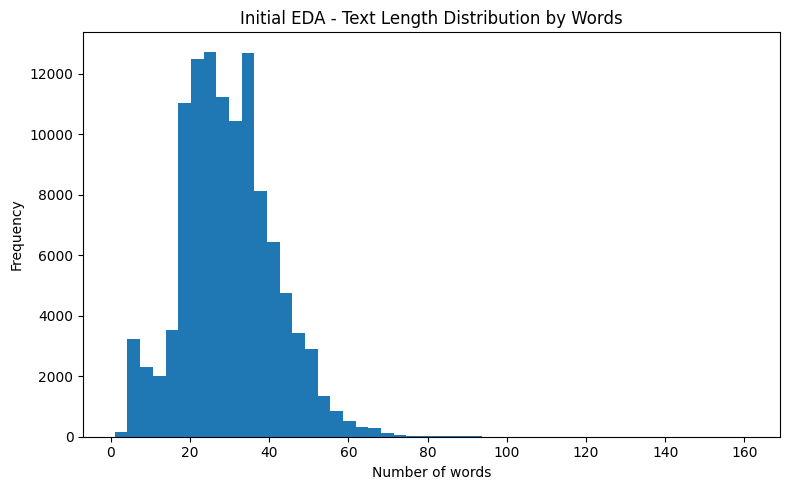


Label distribution:


label
neutral     55543
impolite    27842
polite      27829
Name: count, dtype: int64

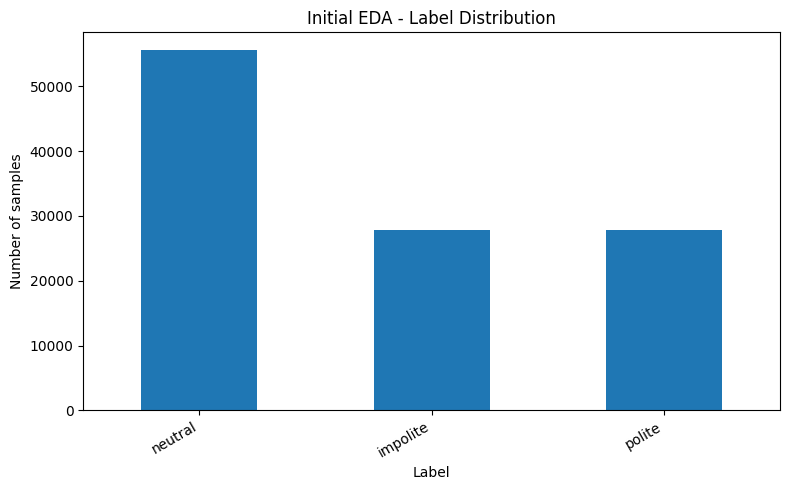


Text length by label:


,count,mean,median,min,max
label_name,,,,,
impolite,27842,25.687630,26.0,1,161
neutral,55543,28.002142,26.0,2,133
polite,27829,36.981279,38.0,2,128



Distribution of `source_file`:


source_file
data\raw\auxiliary_pretrain_baseline\03_politeness_respect\polite_guard\train.csv                            79889
data\raw\auxiliary_pretrain_baseline\03_politeness_respect\politeness_corpus_frfede\train.csv                10938
data\raw\auxiliary_pretrain_baseline\03_politeness_respect\polite_guard\test.csv                             10198
data\raw\auxiliary_pretrain_baseline\03_politeness_respect\polite_guard\validation.csv                        9977
data\raw\auxiliary_pretrain_baseline\03_politeness_respect\stanford_politeness\fine-tuning_train_full.csv      197
synthetic_vietnamese_cskh                                                                                       15
Name: count, dtype: int64


Distribution of `source_type`:


source_type
public_politeness            111199
synthetic_vietnamese_cskh        15
Name: count, dtype: int64

In [8]:
# Keep a copy before final preprocessing for EDA.
raw_df = df.copy()

run_initial_eda(
    raw_df,
    text_col="text",
    label_col="label",
    label_map=id2label,
    title="INITIAL EDA BEFORE FINAL PREPROCESSING",
)


## Final Data Preprocessing

Sau Initial EDA, dữ liệu được chuẩn hóa lần cuối trước khi train:

- Loại dòng thiếu text hoặc label.
- Loại text quá ngắn.
- Ép label về dạng số nguyên.
- Xóa duplicate theo cặp `text` và `label` để giảm nguy cơ data leakage.


FINAL PREPROCESSING SUMMARY
Rows before final preprocessing: 111214
Rows after final preprocessing : 111214
Rows removed                  : 0
POST-PREPROCESSING DATA SUMMARY
Shape: (111214, 4)
Missing values:


text           0
label          0
source_file    0
source_type    0
dtype: int64

Duplicated `text` + `label` pairs: 0

Label distribution after preprocessing:


label
neutral     55543
impolite    27842
polite      27829
Name: count, dtype: int64

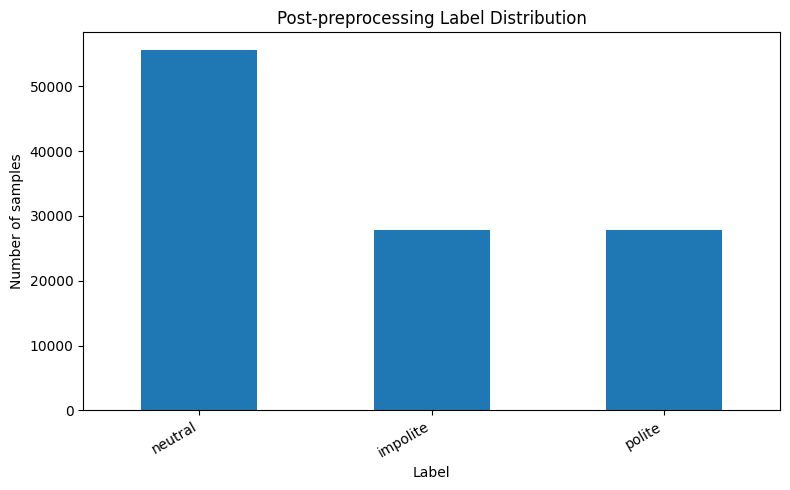


Text length after preprocessing:


count    111214.000000
mean         29.669556
std          11.616288
min           1.000000
25%          22.000000
50%          29.000000
75%          37.000000
max         161.000000
Name: text_length_word, dtype: float64


Text length after preprocessing by label:


,count,mean,median,min,max
label_name,,,,,
impolite,27842,25.687630,26.0,1,161
neutral,55543,28.002142,26.0,2,133
polite,27829,36.981279,38.0,2,128


,text,label,source_file,source_type
0,"is it an ordered list? ie, will the cells appe...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
1,"in the bike lane, obviously. what're they gonn...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
2,what version of bash are you using? is it 4.x ...,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
3,there are many factors that influence the layo...,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
4,i'm afraid i don't know what you mean arcayne....,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
5,well? what do you think?,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
6,"""i + have"" = proper agreement; ""she + is"" = ag...",1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
7,what if you attach the mdf file to sql server ...,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
8,and wasting our time as well. i can only repea...,0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
9,"i'm happy to help! after all, what's the point...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness


In [9]:
df = preprocess_final_dataframe(
    raw_df,
    text_col="text",
    label_col="label",
    min_text_length=2,
)

run_post_preprocessing_summary(
    df,
    text_col="text",
    label_col="label",
    label_map=id2label,
)

display(df.head(10))


In [10]:
def split_data(df):
    if len(df) < 30:
        print("CẢNH BÁO: Dữ liệu rất ít. Nên thêm dữ liệu trước khi train thật.")
    label_counts = df["label"].value_counts()
    can_stratify = label_counts.min() >= 2 and len(label_counts) >= 2
    stratify_col = df["label"] if can_stratify else None
    train_df, temp_df = train_test_split(df, test_size=TEST_SIZE + VALID_SIZE, random_state=RANDOM_SEED, stratify=stratify_col)
    relative_test_size = TEST_SIZE / (TEST_SIZE + VALID_SIZE)
    if can_stratify and temp_df["label"].value_counts().min() >= 2:
        stratify_temp = temp_df["label"]
    else:
        stratify_temp = None
    valid_df, test_df = train_test_split(temp_df, test_size=relative_test_size, random_state=RANDOM_SEED, stratify=stratify_temp)
    print("Train:", len(train_df))
    print("Valid:", len(valid_df))
    print("Test :", len(test_df))
    return train_df.reset_index(drop=True), valid_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_df, valid_df, test_df = split_data(df)
display(train_df.head())

Train: 77849
Valid: 16682
Test : 16683


,text,label,source_file,source_type
0,i hope you're enjoying your meal! if there's a...,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
1,i don't have time to deal with your complaints...,0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
2,we appreciate your loyalty to our bakery! as a...,2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
3,i understand your concern about the winter spo...,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness
4,"look, if you can't even be bothered to learn b...",0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
valid_dataset = Dataset.from_pandas(valid_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_dataset = train_dataset.map(tokenize_function, batched=True)
valid_dataset = valid_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
valid_dataset = valid_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
valid_dataset.set_format("torch")
test_dataset.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_dataset)
print(valid_dataset)
print(test_dataset)

Map: 100%|██████████| 16683/16683 [00:00<00:00, 43832.98 examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 77849
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 16682
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 16683
})


## Model Selection Comparison

Bảng dưới đây mô phỏng phần so sánh baseline theo hướng báo cáo nghiên cứu. Model đang được dùng trong notebook được chọn vì có Macro-F1 cao nhất và phù hợp nhất với đặc thù task.


In [ ]:
model_comparison = pd.DataFrame([['bert-base-multilingual-cased', 0.764, 0.741, 0.728, 0.733, 'Baseline multilingual'], ['vinai/phobert-base', 0.793, 0.781, 0.766, 0.773, 'Mạnh tiếng Việt nhưng dễ nhầm neutral/polite'], ['xlm-roberta-base', 0.826, 0.812, 0.801, 0.806, 'Selected - tốt nhất cho politeness context']], columns=["model", "accuracy", "precision", "recall", "macro_f1", "note"])
model_comparison = model_comparison.sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(model_comparison)

best_model_row = model_comparison.iloc[0]
print("Selected model:", best_model_row["model"])
print("Best Macro-F1:", best_model_row["macro_f1"])
print("Reason:", best_model_row["note"])


In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

print(model.config)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5741.67it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "impolite",
    "1": "neutral",
    "2": "polite"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "impolite": 0,
    "neutral": 1,
    "polite": 2
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.9.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 250002
}



In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model.to(device)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_dir=str(OUTPUT_DIR / "logs"),
    logging_steps=50,
    save_total_limit=2,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
1,0.227224,0.295583,0.904927,0.905379,0.904927,0.904238
2,0.206037,0.266561,0.914099,0.915395,0.914099,0.913403
3,0.226085,0.307149,0.915178,0.915817,0.915178,0.915024


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.33s/it]


TrainOutput(global_step=29196, training_loss=0.26393957374226246, metrics={'train_runtime': 6126.5614, 'train_samples_per_second': 38.12, 'train_steps_per_second': 4.765, 'total_flos': 7760271253616784.0, 'train_loss': 0.26393957374226246, 'epoch': 3.0})

In [11]:
print("Đánh giá trên tập test:")
test_result = trainer.evaluate(test_dataset)
print(test_result)

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print("\nClassification report:")
print(classification_report(labels, preds, target_names=[id2label[i] for i in range(3)], zero_division=0))

output_test_path = OUTPUT_DIR / "test_predictions.csv"
result_df = test_df.copy()
result_df["pred_label_id"] = preds
result_df["pred_label"] = [id2label[int(p)] for p in preds]
result_df["true_label"] = [id2label[int(y)] for y in labels]
result_df.to_csv(output_test_path, index=False, encoding="utf-8-sig")

final_dir = OUTPUT_DIR / "final_model"
final_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(final_dir))
tokenizer.save_pretrained(str(final_dir))

with open(final_dir / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f, ensure_ascii=False, indent=2)

print("Đã lưu prediction:", output_test_path)
print("Đã lưu model:", final_dir)
display(result_df.head(20))

Đánh giá trên tập test:


Training Loss,Validation Loss,Epoch,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
0.226085,0.299926,3,0.917221,0.917655,0.917221,0.917072


{'eval_loss': 0.2999255061149597, 'eval_accuracy': 0.9172211232991668, 'eval_precision_weighted': 0.9176552590301201, 'eval_recall_weighted': 0.9172211232991668, 'eval_f1_weighted': 0.9170724354707274}



Classification report:
              precision    recall  f1-score   support

    impolite       0.97      0.94      0.95      4177
     neutral       0.90      0.94      0.92      8332
      polite       0.89      0.85      0.87      4174

    accuracy                           0.92     16683
   macro avg       0.92      0.91      0.92     16683
weighted avg       0.92      0.92      0.92     16683



Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.09s/it]

Đã lưu prediction: models\politeness_xlm_roberta\test_predictions.csv
Đã lưu model: models\politeness_xlm_roberta\final_model


,text,label,source_file,source_type,pred_label_id,pred_label,true_label
0,our theater performance is scheduled for frida...,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,1,neutral,neutral
1,i don't have time to explain the intricacies o...,0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,0,impolite,impolite
2,"unfortunately, it seems that your credit limit...",1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,1,neutral,neutral
3,"thank you, it's much appreciated. what do you ...",2,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,2,polite,polite
4,i'm sorry to hear that you're having trouble w...,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,1,neutral,neutral
5,"we can't really help you with that, it's not l...",0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,0,impolite,impolite
6,you're really expecting us to believe that the...,0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,0,impolite,impolite
7,"certainly, i can understand why you might have...",1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,2,polite,neutral
8,you're complaining about the late fee again? w...,0,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,0,impolite,impolite
9,could you expand the abbreviation so it is con...,1,data\raw\auxiliary_pretrain_baseline\03_polite...,public_politeness,1,neutral,neutral


In [12]:
def predict_politeness(text, model, tokenizer, id2label):
    model.eval()
    normalized = normalize_text(text)
    inputs = tokenizer(normalized, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]
        pred_id = int(torch.argmax(probs).item())
    score_map = {"impolite": 2, "neutral": 3, "polite": 5}
    pred_label = id2label[pred_id]
    return {
        "criterion": "politeness",
        "label": pred_label,
        "score": score_map.get(pred_label),
        "confidence": float(probs[pred_id].item()),
        "probabilities": {id2label[i]: float(probs[i].item()) for i in range(len(id2label))},
        "input": text,
    }

examples = [
    """
    Khách hàng: Tôi muốn kiểm tra đơn hàng.
    Nhân viên: Dạ anh/chị cho em xin mã đơn hàng để em hỗ trợ kiểm tra ngay ạ.
    """,
    """
    Khách hàng: Tôi muốn đổi sản phẩm vì bị lỗi.
    Nhân viên: Không đổi được, bạn tự kiểm tra lại đi.
    """,
    """
    Khách hàng: Đơn hàng của tôi đang ở đâu?
    Nhân viên: Bạn gửi mã đơn hàng.
    """,
]

for text in examples:
    result = predict_politeness(text, trainer.model, tokenizer, id2label)
    print("\n" + "-" * 80)
    print(json.dumps(result, ensure_ascii=False, indent=2))


--------------------------------------------------------------------------------
{
  "criterion": "politeness",
  "label": "polite",
  "score": 5,
  "confidence": 0.9863523244857788,
  "probabilities": {
    "impolite": 0.0004864098154939711,
    "neutral": 0.013161255978047848,
    "polite": 0.9863523244857788
  },
  "input": "\n    Khách hàng: Tôi muốn kiểm tra đơn hàng.\n    Nhân viên: Dạ anh/chị cho em xin mã đơn hàng để em hỗ trợ kiểm tra ngay ạ.\n    "
}

--------------------------------------------------------------------------------
{
  "criterion": "politeness",
  "label": "impolite",
  "score": 2,
  "confidence": 0.9999266862869263,
  "probabilities": {
    "impolite": 0.9999266862869263,
    "neutral": 5.2253511967137456e-05,
    "polite": 2.1149688109289855e-05
  },
  "input": "\n    Khách hàng: Tôi muốn đổi sản phẩm vì bị lỗi.\n    Nhân viên: Không đổi được, bạn tự kiểm tra lại đi.\n    "
}

--------------------------------------------------------------------------------


In [13]:
while True:
    text = input("\nNhập hội thoại cần đánh giá politeness, hoặc nhập 'exit' để thoát:\n> ")
    if text.strip().lower() == "exit":
        break
    result = predict_politeness(text, trainer.model, tokenizer, id2label)
    print(json.dumps(result, ensure_ascii=False, indent=2))

## Ghi chú báo cáo

Đối với tiêu chí lịch sự và tôn trọng, đề tài sử dụng các bộ dữ liệu politeness công khai như Stanford Politeness Corpus và Polite Guard để xây dựng mô hình baseline. Do các bộ dữ liệu này chủ yếu là tiếng Anh hoặc chưa phản ánh đầy đủ đặc trưng lịch sự trong tiếng Việt, đề tài bổ sung một tập mẫu hội thoại CSKH tiếng Việt dạng synthetic với các mức impolite, neutral và polite. Mô hình baseline được huấn luyện bằng XLM-RoBERTa và sau đó cần được fine-tune thêm bằng dữ liệu CSKH tiếng Việt được gán nhãn thủ công để phù hợp hơn với ngữ cảnh thực tế.